# Instance segmentation of BabyView object crops

### Grouping crops by the *individual physical object* they show

This notebook documents, step by step, how we group the crops **within each
category** into estimated **object instances** — separating *one* clock seen
many times from *many* different books. It is the exploratory analysis behind
the "Object instances" panel of the
[BabyView variability explorer](https://vislearnlab.github.io/babyview-variability-explorer/).

**Why we do this.** The CCN 2026 abstract
(*Variability in Young Children's Everyday Visual Experiences of Object
Categories*) measures how visually variable each category is, but notes a
limitation:

> "our metrics do not distinguish between different sources of exemplar
> variability" — e.g. one cup from many angles vs. many different cups.

Instance segmentation is a first cut at that decomposition: if we can count how
many *distinct objects* a category contains, we can ask whether a category's
dispersion reflects **how many different things it holds** vs. **how variably
each thing is seen**.

**What you will see.**
1. Load the public crops and their DINOv3 embeddings.
2. Show *why* we use DINOv3 and not CLIP for this.
3. Explain and calibrate the clustering (agglomerative, cosine, average linkage).
4. Run it on all 72 categories and build validation montages.
5. Probe the biggest confound — the frame **sampling** — head on.
6. Relate instance diversity to the paper's local vs. global dispersion.

Every code cell is short and preceded by a plain-language explanation of what it
does and *why*.

> **Data note.** Everything here uses the **public, privacy-filtered** release
> (5,921 crops, 72 categories; body-part categories withheld). Filenames are
> opaque stems — there is **no video, frame, or timestamp metadata**. That
> absence matters for the sampling caveat in §5.

## 0 · Setup

We need only the standard scientific-Python stack plus scikit-learn's
`AgglomerativeClustering`. No deep-learning framework is required at analysis
time — the DINOv3 embeddings are already computed and stored as `.npy` files, so
this notebook is pure CPU and runs in well under a minute.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
from numpy.linalg import norm
from PIL import Image
from scipy.stats import spearmanr
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

# Resolve the repo root whether the notebook runs from notebooks/ or the root.
REPO = Path.cwd()
if REPO.name == "notebooks":
    REPO = REPO.parent
PUBLIC = REPO / "data" / "valid7018_public"
assert (PUBLIC / "embeddings").exists(), "unzip data/valid7018_public/embeddings.zip first"
print("repo:", REPO)

repo: /Users/brialong/Documents/GitHub/object-detection-clip-layers


## 1 · Load the crops and their DINOv3 embeddings

Each crop has a paired **DINOv3 ViT-B/16** embedding (768-d) shipped in the
public release. The embeddings were stored **feature-wise z-scored** (each
dimension centered and scaled using statistics fit on all 7,018 validated
crops). For *similarity* comparisons we want the vectors back in their original
scale, so we undo that z-score with the stored μ and σ.

Line by line, the next cell:

1. reads the manifest that pairs every `(category, stem)` with its `.npy` file;
2. loads the stored z-score μ/σ for DINOv3;
3. loads each vector and **de-normalizes** it (`v * σ + μ`) back to raw space;
4. stacks them into one `(5921, 768)` matrix aligned with the manifest rows.

In [2]:
man = pd.read_csv(PUBLIC / "embeddings" / "manifest.csv")          # category, stem, clip_npy, dinov3_npy
stats = json.loads((PUBLIC / "embedding_norm_stats.json").read_text())["models"]["dinov3"]
mu, sigma = np.array(stats["mu"]), np.array(stats["sigma"])         # (768,), (768,)

dino = np.stack([
    np.load(PUBLIC / "embeddings" / p).astype(np.float32) * sigma + mu   # undo the z-score
    for p in man.dinov3_npy
])
categories = man.category.values
print(dino.shape, "embeddings across", man.category.nunique(), "categories")

(5921, 768) embeddings across 72 categories


For a similarity-based method, the natural distance is **cosine** — the angle
between two embedding vectors, insensitive to their magnitude. The clean way to
get cosine similarity is to **L2-normalize** every vector to unit length; then a
plain dot product *is* the cosine, and Euclidean distance becomes a monotal
function of it. We normalize once, up front.

In [3]:
dino_unit = dino / np.clip(norm(dino, axis=1, keepdims=True), 1e-8, None)
# sanity: every row now has length 1
print("norms:", norm(dino_unit, axis=1)[:3], "...")

norms: [1. 1. 1.] ...


## 2 · Why DINOv3 and not CLIP?

The release also ships CLIP embeddings, so which should we cluster on? For
**instance** grouping we need features that separate *this* clock from *that*
clock — an appearance/identity signal, not just "clock-ness."

We test this directly: for every crop, find its **most similar same-category
neighbor** and record that cosine. If a model discriminates instances, most
crops will have only a *moderately* similar best match (different objects), with
a small tail of very-high matches (the same object seen again). If a model
collapses everything to "same category," *all* best matches will be near 1.

The next cell computes that best-same-category-neighbor cosine for both models.

In [4]:
def best_same_cat_cosine(emb_unit):
    "For each crop, the cosine to its most similar OTHER crop in the same category."
    out = []
    for c in np.unique(categories):
        idx = np.where(categories == c)[0]
        if len(idx) < 3:
            continue
        S = emb_unit[idx] @ emb_unit[idx].T   # pairwise cosine within the category
        np.fill_diagonal(S, -1)               # ignore self-matches
        out.append(S.max(axis=1))             # best neighbor per crop
    return np.concatenate(out)

# CLIP, de-normalized the same way, for the comparison
cstats = json.loads((PUBLIC / "embedding_norm_stats.json").read_text())["models"]["clip"]
cmu, csig = np.array(cstats["mu"]), np.array(cstats["sigma"])
clip = np.stack([np.load(PUBLIC / "embeddings" / p).astype(np.float32) * csig + cmu for p in man.clip_npy])
clip_unit = clip / np.clip(norm(clip, axis=1, keepdims=True), 1e-8, None)

d_best = best_same_cat_cosine(dino_unit)
c_best = best_same_cat_cosine(clip_unit)
print(f"DINOv3: median {np.median(d_best):.3f}, frac>0.9 {np.mean(d_best>0.9):.3f}")
print(f"CLIP:   median {np.median(c_best):.3f}, frac>0.9 {np.mean(c_best>0.9):.3f}")

DINOv3: median 0.605, frac>0.9 0.013
CLIP:   median 0.910, frac>0.9 0.614


The histogram makes the difference obvious.

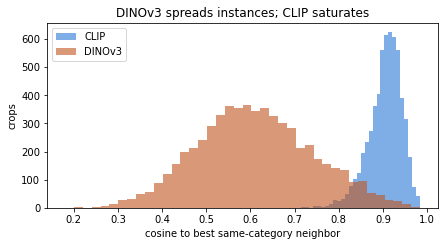

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.hist(c_best, bins=40, alpha=0.6, label="CLIP", color="#2a78d6")
ax.hist(d_best, bins=40, alpha=0.6, label="DINOv3", color="#c0561f")
ax.set_xlabel("cosine to best same-category neighbor")
ax.set_ylabel("crops"); ax.legend(); ax.set_title("DINOv3 spreads instances; CLIP saturates")
plt.show()

**Reading it.** CLIP piles up near ~0.91 for *everything* — two unrelated books
look ~as similar as two views of one book, so it cannot separate instances.
DINOv3 has a broad distribution with only a small high-similarity tail: exactly
the shape we want, where "same object again" stands out from "different object."
**We cluster on DINOv3.**

## 3 · The clustering method

We use **agglomerative (hierarchical) clustering** with:

- **metric = cosine** — distance is `1 − cosine_similarity`, matching §2;
- **linkage = average** — two clusters merge based on the *average* pairwise
  distance between their members (more robust to a single stray crop than
  single-linkage, less rigid than complete-linkage);
- **distance_threshold = 1 − τ** — instead of asking for a fixed *number* of
  clusters (we don't know how many objects a category has!), we merge everything
  closer than a cosine cutoff **τ** and let the number of clusters fall out.
  Each resulting cluster is one **estimated instance**.

The one free parameter is **τ**. Higher τ = stricter (only near-identical crops
merge → more, smaller instances); lower τ = looser (more merging → fewer, larger
instances). §3.1 calibrates it.

In [6]:
def cluster_category(emb_unit_cat, tau):
    "Return an instance label per crop for one category's unit embeddings."
    if len(emb_unit_cat) < 2:
        return np.zeros(len(emb_unit_cat), dtype=int)
    model = AgglomerativeClustering(
        n_clusters=None,             # let the threshold decide the count
        distance_threshold=1 - tau,  # merge if cosine >= tau
        metric="cosine",
        linkage="average",
    )
    return model.fit_predict(emb_unit_cat)

### 3.1 · Calibrating the threshold τ

There is no ground truth, so we calibrate by **contrast**: pick categories we
have strong priors about and check that τ separates them sensibly.

- **clock, oven** — stationary household objects; the *same* one recurs, so we
  expect real repeat-groups.
- **book, car** — we expect almost every crop to be a *different* object.

We sweep τ and watch the number of multi-crop instances. A good τ gives clock
meaningful groups while keeping book/car almost all singletons.

In [7]:
for c in ["clock", "oven", "book", "car"]:
    e = dino_unit[categories == c]
    print(f"\n{c} (n={len(e)}):")
    for tau in [0.90, 0.85, 0.80, 0.75]:
        lab = cluster_category(e, tau)
        sizes = np.bincount(lab)
        print(f"  tau>{tau}: {lab.max()+1:3d} instances, "
              f"{(sizes>=2).sum():2d} repeated, largest={sizes.max()}")


clock (n=92):
  tau>0.9:  83 instances,  5 repeated, largest=5
  tau>0.85:  66 instances, 15 repeated, largest=9
  tau>0.8:  48 instances, 18 repeated, largest=13
  tau>0.75:  36 instances, 15 repeated, largest=13

oven (n=83):
  tau>0.9:  82 instances,  1 repeated, largest=2
  tau>0.85:  80 instances,  2 repeated, largest=3
  tau>0.8:  72 instances,  9 repeated, largest=3
  tau>0.75:  67 instances,  8 repeated, largest=8

book (n=94):
  tau>0.9:  94 instances,  0 repeated, largest=1
  tau>0.85:  94 instances,  0 repeated, largest=1
  tau>0.8:  94 instances,  0 repeated, largest=1
  tau>0.75:  93 instances,  1 repeated, largest=2

car (n=69):
  tau>0.9:  69 instances,  0 repeated, largest=1
  tau>0.85:  69 instances,  0 repeated, largest=1
  tau>0.8:  68 instances,  1 repeated, largest=2
  tau>0.75:  68 instances,  1 repeated, largest=2


`clock` develops real repeat-groups as τ drops, while `book`/`car` stay almost
entirely singletons until τ is implausibly loose. **τ = 0.80** is the operating
point: it recovers repeats where they should exist and withholds them where they
shouldn't. (This is a judgement call, made transparent — not a tuned optimum.)

In [8]:
TAU = 0.80

## 4 · Cluster every category

We now run the clustering for all 72 categories and record, per category:

- **n_crops**, **n_instances** (number of clusters),
- **instances_per_crop** = n_instances / n_crops — **1.0 means every crop is a
  distinct object**; lower means more repetition,
- **repeat_rate** = 1 − instances_per_crop — fraction of crops that repeat an
  object already counted.

In [9]:
rows, labels_by_cat = [], {}
for c in np.unique(categories):
    idx = np.where(categories == c)[0]
    lab = cluster_category(dino_unit[idx], TAU)
    labels_by_cat[c] = (idx, lab)
    n, k = len(idx), int(lab.max() + 1)
    sizes = np.bincount(lab)
    rows.append(dict(category=c, n_crops=n, n_instances=k,
                     instances_per_crop=k / n, repeat_rate=1 - k / n,
                     n_repeated=int((sizes >= 2).sum()), largest=int(sizes.max())))
counts = pd.DataFrame(rows)
print(f"{counts.n_instances.sum()} estimated objects across {counts.n_crops.sum()} crops "
      f"({100*(1-counts.n_instances.sum()/counts.n_crops.sum()):.0f}% of crops are repeats)")
counts.sort_values("instances_per_crop").head(8)

5642 estimated objects across 5921 crops (5% of crops are repeats)


,category,n_crops,n_instances,instances_per_crop,repeat_rate,n_repeated,largest
18,clock,92,48,0.521739,0.478261,18,13
58,slide,57,39,0.684211,0.315789,6,10
13,butterfly,92,65,0.706522,0.293478,11,7
48,pony,63,50,0.793651,0.206349,8,5
38,lamp,92,76,0.826087,0.173913,9,5
61,stroller,88,74,0.840909,0.159091,7,4
56,shower,77,65,0.844156,0.155844,7,6
41,oven,83,72,0.867470,0.132530,9,3


The most-repeated categories (lowest `instances_per_crop`) are stationary
household objects; the all-distinct ones are things that are rarely the *same*
physical object twice.

In [10]:
counts.sort_values("instances_per_crop", ascending=False).head(6)[["category","n_crops","instances_per_crop"]]

,category,n_crops,instances_per_crop
37,jeans,84,1.0
53,shirt,91,1.0
26,doll,89,1.0
60,stick,73,1.0
62,sweater,97,1.0
64,table,94,1.0


### 4.1 · Validation montages — *look at the clusters*

Numbers mean nothing until we see the groups. For a category, we render one row
per estimated instance (largest groups first): if the method works, each row of
a repeat-heavy category should be visibly the **same physical object**.

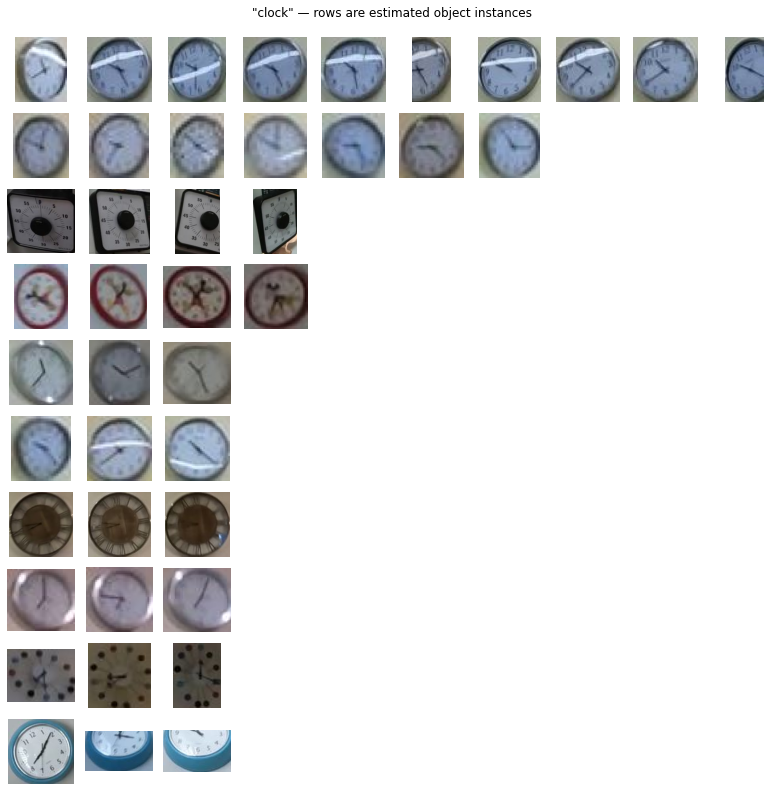

In [11]:
def show_instance_montage(cat, max_rows=10, max_cols=10, cell=90):
    idx, lab = labels_by_cat[cat]
    crop_man = pd.read_csv(PUBLIC / "crops" / "manifest.csv").set_index(["category", "stem"])
    order = np.argsort(-np.bincount(lab))                    # biggest instances first
    groups = [np.where(lab == g)[0] for g in order][:max_rows]
    fig, axes = plt.subplots(len(groups), max_cols,
                             figsize=(max_cols*1.1, len(groups)*1.1))
    axes = np.atleast_2d(axes)
    for r, g in enumerate(groups):
        for col in range(max_cols):
            ax = axes[r, col]; ax.axis("off")
            if col < len(g):
                stem = man.loc[idx[g[col]], "stem"]
                jp = crop_man.loc[(cat, stem), "jpeg_path"]
                ax.imshow(Image.open(PUBLIC / "crops" / jp).convert("RGB"))
        axes[r, 0].set_ylabel(f"x{len(g)}", rotation=0, labelpad=14,
                              va="center", fontsize=9)
    fig.suptitle(f'"{cat}" — rows are estimated object instances', y=0.995)
    plt.tight_layout(); plt.show()

show_instance_montage("clock")   # expect: each row is one recurring clock

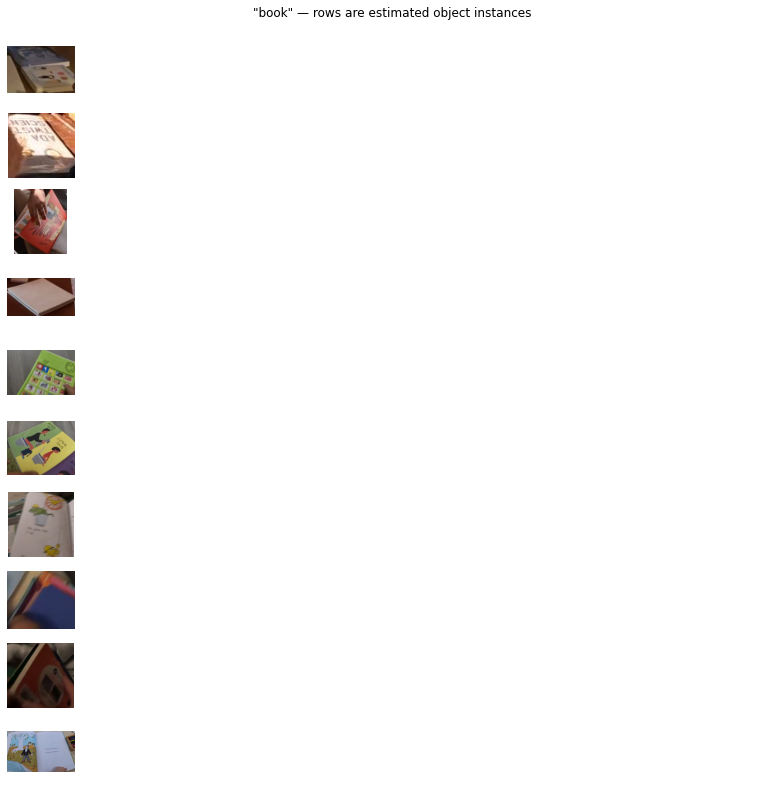

In [12]:
show_instance_montage("book")    # expect: (almost) every crop its own row — all distinct

`clock` shows tidy rows of the *same* clock (a white wall clock, a black timer, a
blue clock…); `book` is essentially one-per-row — every book is different. The
grouping is doing what its name claims.

## 5 · The sampling confound — taken seriously

Before relating instances to dispersion, we must confront the biggest threat to
interpretation: **the crops were sampled from video frames.** A **stationary,
persistent** object (a wall clock) appears in *many* frames, so it contributes
many crops. That means a low `instances_per_crop` might reflect **object
persistence and frame-sampling density**, not "the child encountered fewer
distinct objects."

There are two versions of this worry, and they need separating:

- **(a) Near-identical duplicate frames.** If repeat-groups are just the same
  view sampled over and over, the "instances" are trivial artifacts.
- **(b) Persistence.** Even with *varied* views, a persistent object is sampled
  more, inflating repetition relative to a transient object seen once.

We can test **(a)** with the public data. We **cannot** test **(b)** — it needs
frame timestamps / session IDs, which the public release strips. Be explicit
about that boundary.

In [13]:
# (a): how similar are crops WITHIN a repeat-group? Near-1 => duplicate-frame-like;
#      a spread around 0.80-0.90 => same object seen from genuinely different views.
within = []
for c in np.unique(categories):
    idx, lab = labels_by_cat[c]
    e = dino_unit[idx]
    for g in range(lab.max() + 1):
        m = np.where(lab == g)[0]
        if len(m) < 2:
            continue
        S = e[m] @ e[m].T
        within.append(S[np.triu_indices(len(m), 1)])
within = np.concatenate(within)
print(f"within-instance cosine (n_pairs={len(within)}): median {np.median(within):.3f}, "
      f"frac>0.95 {np.mean(within>0.95):.2f}, frac 0.80-0.90 {np.mean((within>=.8)&(within<.9)):.2f}")

within-instance cosine (n_pairs=542): median 0.844, frac>0.95 0.02, frac 0.80-0.90 0.82


**Result.** The within-instance similarities cluster around **0.84**, with ~82%
in 0.80–0.90 and only ~2% above 0.95. So version **(a) is largely ruled out** —
these are the same object across *different* views, not duplicated frames.

**Version (b) stands.** Persistence-driven over-sampling would still lower local
dispersion for stationary objects. So the honest framing for §6 is: instance
repetition is entangled with **how frames were sampled**, and any relationship
to dispersion should be read as *"local dispersion partly reflects object
persistence/repetition in the sample,"* not a clean count of the child's
distinct exemplars. Resolving (b) is a question for the **full, non-public data**
(with temporal metadata) and for how the 57–100 crops/category were sampled.

## 6 · Does instance diversity index the paper's dispersion?

Finally, the payoff question. The abstract reports two dispersion metrics per
category (computed on the **final** embeddings):

- **global** — mean distance to the category centroid (overall spread);
- **local** — mean k-NN distance, k = 5 (how tight nearest neighbors are).

We ask whether `instances_per_crop` (from **DINOv3** clustering) predicts each.
To avoid circularity, we relate it to the **CLIP** dispersion the paper
published — a *cross-model* check: DINOv3 says how many objects, CLIP says how
spread out.

In [14]:
base = pd.read_csv(REPO / "results" / "metrics" / "baseline_category_metrics.csv")
clip_disp = base[base.source == "released_clip"].set_index("category")
m = counts.set_index("category")
common = m.index.intersection(clip_disp.index)

for name, col in [("local (kNN)", "mean_knn_dist"), ("global", "global_dispersion")]:
    rho, p = spearmanr(m.loc[common, "instances_per_crop"], clip_disp.loc[common, col])
    print(f"instances_per_crop vs {name:12s}: rho={rho:+.3f}  p={p:.3g}")

instances_per_crop vs local (kNN) : rho=+0.295  p=0.0119
instances_per_crop vs global      : rho=+0.162  p=0.174


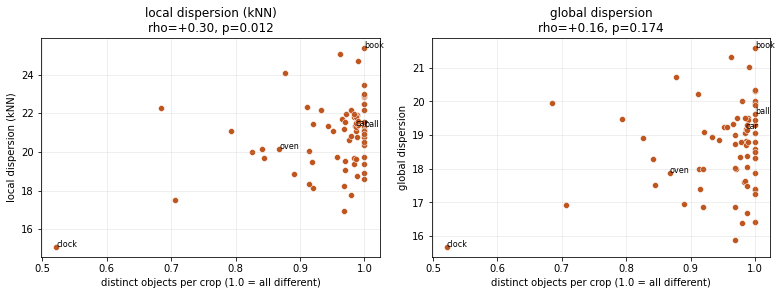

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for a, (name, col) in zip(ax, [("local dispersion (kNN)", "mean_knn_dist"),
                               ("global dispersion", "global_dispersion")]):
    x = m.loc[common, "instances_per_crop"]; y = clip_disp.loc[common, col]
    a.scatter(x, y, s=36, color="#c0561f", edgecolors="white", lw=.5)
    rho, p = spearmanr(x, y)
    a.set_title(f"{name}\nrho={rho:+.2f}, p={p:.3f}")
    a.set_xlabel("distinct objects per crop (1.0 = all different)")
    a.set_ylabel(name); a.grid(alpha=.25)
    for cat in ["clock", "book", "car", "oven", "ball"]:
        if cat in common:
            a.annotate(cat, (m.loc[cat, "instances_per_crop"], clip_disp.loc[cat, col]), fontsize=8)
plt.tight_layout(); plt.show()

**Finding.** Instance diversity tracks **local** dispersion (positive,
significant) but **not global** (≈ 0). The mechanism is intuitive: repeated
near-duplicate-ish views of one object make some nearest-neighbor distances
small, so categories with more repetition have lower local dispersion. Global
spread — the overall range of appearances/viewpoints — is a different quantity
and does not care how many distinct objects produced it.

**But read it through §5.** Because instance repetition is confounded with
frame-sampling/persistence, the honest statement is:

> *Local dispersion partly reflects object persistence/repetition in the sampled
> crops; global dispersion reflects appearance/viewpoint range independent of
> object count.*

This is a first, public-data decomposition of the "sources of variability" the
abstract flagged as open — suggestive, not confirmatory (n = 72, body parts
excluded, sampling unresolved).

## Summary

| Step | What | Takeaway |
|---|---|---|
| §2 | model choice | DINOv3 separates instances; CLIP saturates |
| §3 | method | average-linkage agglomerative, cosine, τ = 0.80 |
| §4 | run + montages | clusters are genuinely same-object (validated by eye) |
| §5 | confound | duplicate-frames ruled out; **persistence not** (needs temporal data) |
| §6 | payoff | instance diversity indexes **local**, not global, dispersion |

**Reproduces:** `scripts/cluster_instances.py` (the non-notebook version) writes
the same CSVs and montages under `results/instances/`. See `notebooks/README.md`
for how to run this notebook.